In [ ]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import mutual_info_classif, chi2, RFE
from scipy.stats import kruskal
from scipy.stats import ttest_ind, mannwhitneyu

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("data.csv")

# Remove ID column if exists
if "ID" in data.columns:
    data = data.drop(columns=["ID"])

X = data.drop("class", axis=1)
y = data["class"]

le = LabelEncoder()
y = le.fit_transform(y)
y = pd.Series(y)

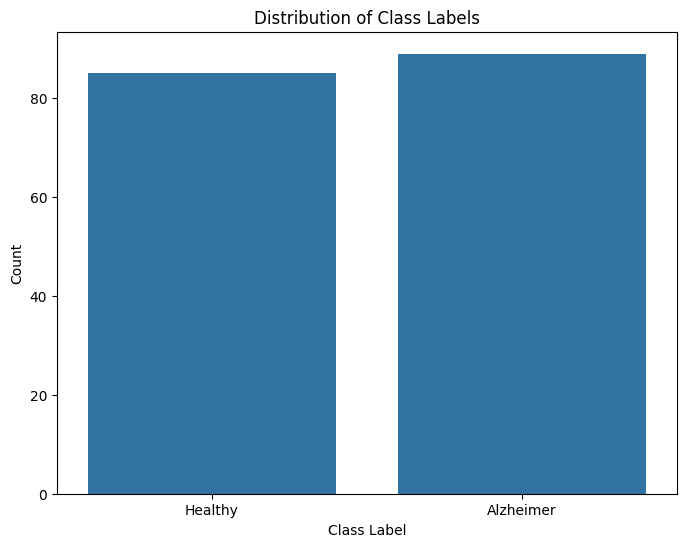

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribution of Class Labels')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Healthy', 'Alzheimer'])
plt.show()

In [ ]:
print(X.columns.tolist())

['air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1', 'max_x_extension1', 'max_y_extension1', 'mean_acc_in_air1', 'mean_acc_on_paper1', 'mean_gmrt1', 'mean_jerk_in_air1', 'mean_jerk_on_paper1', 'mean_speed_in_air1', 'mean_speed_on_paper1', 'num_of_pendown1', 'paper_time1', 'pressure_mean1', 'pressure_var1', 'total_time1', 'air_time2', 'disp_index2', 'gmrt_in_air2', 'gmrt_on_paper2', 'max_x_extension2', 'max_y_extension2', 'mean_acc_in_air2', 'mean_acc_on_paper2', 'mean_gmrt2', 'mean_jerk_in_air2', 'mean_jerk_on_paper2', 'mean_speed_in_air2', 'mean_speed_on_paper2', 'num_of_pendown2', 'paper_time2', 'pressure_mean2', 'pressure_var2', 'total_time2', 'air_time3', 'disp_index3', 'gmrt_in_air3', 'gmrt_on_paper3', 'max_x_extension3', 'max_y_extension3', 'mean_acc_in_air3', 'mean_acc_on_paper3', 'mean_gmrt3', 'mean_jerk_in_air3', 'mean_jerk_on_paper3', 'mean_speed_in_air3', 'mean_speed_on_paper3', 'num_of_pendown3', 'paper_time3', 'pressure_mean3', 'pressure_var3', 'total_time3', 'ai

In [ ]:
print(data.shape)
print(X.shape)
print(y.shape)


(174, 451)
(174, 450)
(174,)


Dropped 111 features. Remaining: 339


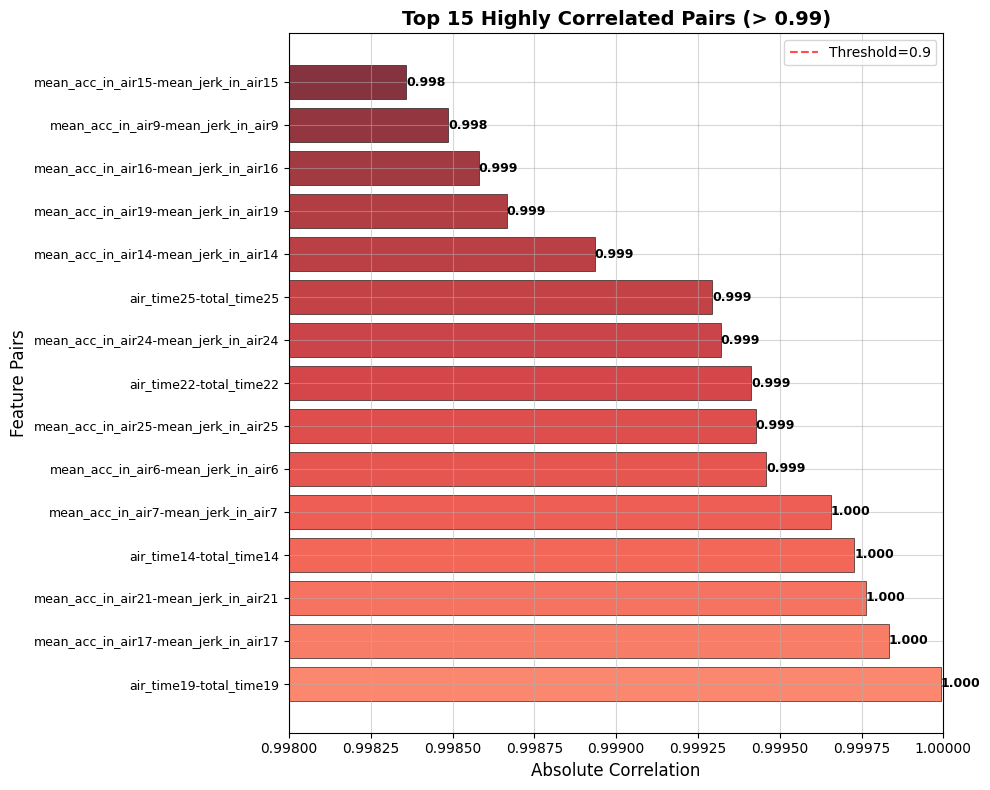

In [ ]:
def drop_highly_correlated_features(X, threshold=0.90):
    """Ultra-optimized: drop features with correlation > threshold"""
    corr_matrix = X.corr().abs()
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

    high_corr_upper = (corr_matrix > threshold) & mask
    to_drop = corr_matrix.columns[high_corr_upper.any()].tolist()

    X_reduced = X.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} features. Remaining: {X_reduced.shape[1]}")
    return X_reduced, corr_matrix

def plot_correlation_bar_chart(corr_matrix, threshold=0.90, max_pairs=15):
    """Horizontal bar chart - No summary panel"""
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    high_corr_pairs = np.where((corr_matrix > threshold) & mask)

    if len(high_corr_pairs[0]) == 0:
        print("No pairs above threshold!")
        return

    # Extract pairs
    pairs = []
    for i, j in zip(high_corr_pairs[0], high_corr_pairs[1]):
        col1, col2 = corr_matrix.index[i], corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        pairs.append((f"{col1}-{col2}", corr_val))

    # Sort by correlation (highest first)
    pairs.sort(key=lambda x: x[1], reverse=True)
    top_pairs = pairs[:max_pairs]

    # Create SINGLE horizontal bar chart
    fig, ax = plt.subplots(1, 1, figsize=(10, max(8, len(top_pairs) * 0.4)))

    # Horizontal bar chart
    labels, values = zip(*top_pairs)
    colors = plt.cm.Reds(np.linspace(0.5, 1, len(values)))

    bars = ax.barh(range(len(labels)), values, color=colors, alpha=0.8,
                   edgecolor='black', linewidth=0.5)

    # Y-axis starts near threshold
    ax.set_xlim(0.998, 1)
    ax.set_xlabel('Absolute Correlation', fontsize=12)
    ax.set_ylabel('Feature Pairs', fontsize=12)
    ax.set_title(f'Top {len(top_pairs)} Highly Correlated Pairs (> 0.99)',
                fontsize=14, fontweight='bold')

    # Threshold line
    ax.axvline(x=threshold, color='red', linestyle='--', alpha=0.7,
               label=f'Threshold={threshold}')
    ax.legend()
    ax.grid(True, alpha=0.5)

    # Value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', ha='left', va='center',
                fontsize=9, fontweight='bold')

    # Set y-ticks
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    plt.tight_layout()
    plt.show()

# Usage
X_reduced, corr_matrix = drop_highly_correlated_features(X.copy())
plot_correlation_bar_chart(corr_matrix)

In [ ]:
def drop_highly_correlated_features(X, threshold=0.90):
    """Ultra-optimized: drop features with correlation > threshold"""
    corr_matrix = X.corr().abs()
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

    # Single vectorized operation to find high correlations
    high_corr_upper = (corr_matrix > threshold) & mask

    # Columns with ANY high correlation in upper triangle
    to_drop = corr_matrix.columns[high_corr_upper.any()].tolist()

    X_reduced = X.drop(columns=to_drop)
    print("Remaining features:", X_reduced.shape[1])
    return X_reduced

# Usage
X = drop_highly_correlated_features(X)

Remaining features: 339


In [ ]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

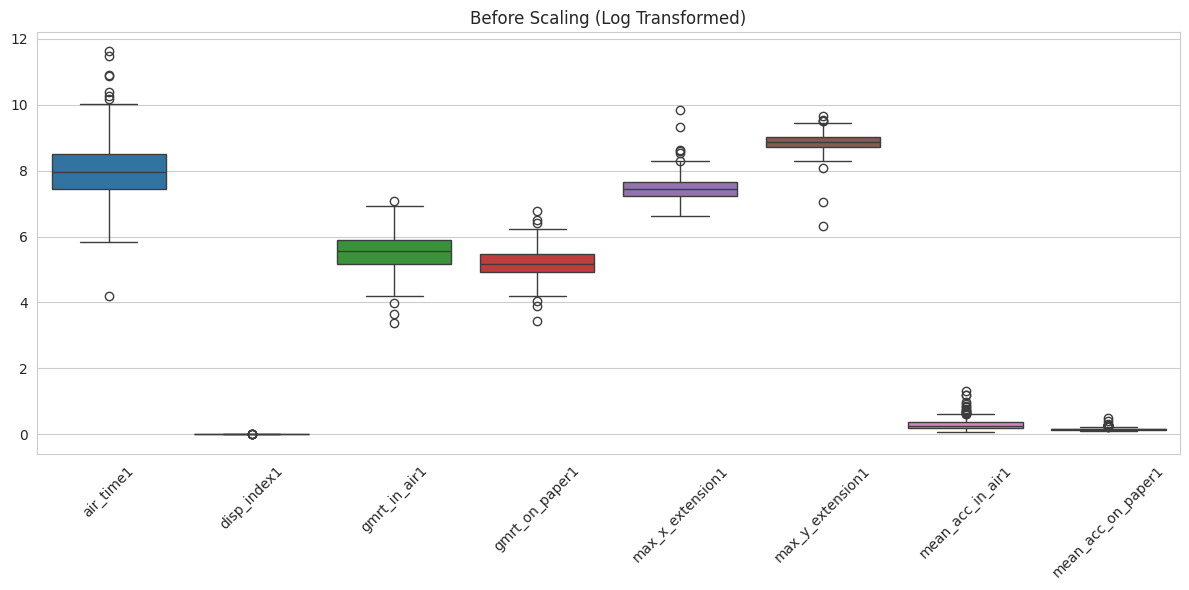

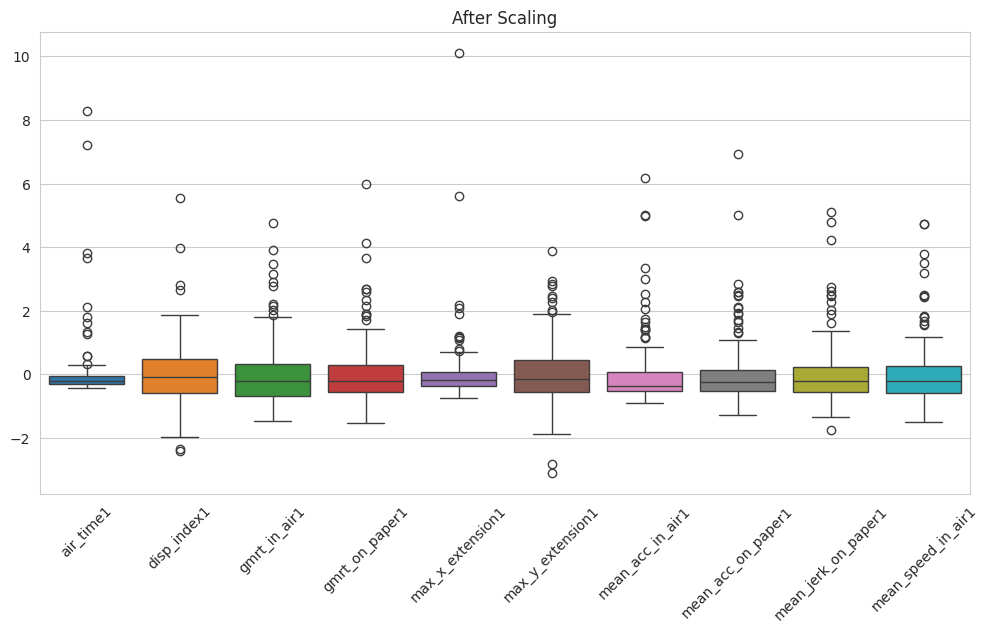

In [ ]:
X_log = np.log1p(X)  # handles large values

plt.figure(figsize=(12,6))
sns.boxplot(data=X_log.iloc[:,:8])
plt.xticks(rotation=45)
plt.title("Before Scaling (Log Transformed)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=X_scaled.iloc[:,:10])
plt.xticks(rotation=45)
plt.title("After Scaling")
plt.show()

In [ ]:
# -----------------------------
# Feature Selection Functions
# -----------------------------

# Mutual Information
def mi_selection(X, y, k):
    scores = mutual_info_classif(X, y)
    indices = np.argsort(scores)[-k:]
    return X.columns[indices]


# T-Test
def ttest_selection(X, y, k):
    scores = []
    class0 = X[y == 0]
    class1 = X[y == 1]

    for col in X.columns:
        stat, p = ttest_ind(class0[col], class1[col])
        scores.append(-np.log10(p))

    indices = np.argsort(scores)[-k:]
    return X.columns[indices]


# Mann Whitney
def mann_selection(X, y, k):
    scores = []
    class0 = X[y == 0]
    class1 = X[y == 1]

    for col in X.columns:
        stat, p = mannwhitneyu(class0[col], class1[col])
        scores.append(-np.log10(p))

    indices = np.argsort(scores)[-k:]
    return X.columns[indices]


# Chi-Square
def chi_selection(X, y, k):

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    chi_scores, _ = chi2(X_scaled, y)

    indices = np.argsort(chi_scores)[-k:]

    return X.columns[indices]


# Random Forest Importance
def rf_selection(X, y, k):

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    rf.fit(X, y)

    indices = np.argsort(rf.feature_importances_)[-k:]

    return X.columns[indices]


# Extra Trees Importance
def et_selection(X, y, k):

    et = ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    )

    et.fit(X, y)

    indices = np.argsort(et.feature_importances_)[-k:]

    return X.columns[indices]


# RFE
def rfe_selection(X, y, k):

    model = LogisticRegression(max_iter=1000)

    rfe = RFE(model, n_features_to_select=k)

    rfe.fit(X, y)

    return X.columns[rfe.support_]


# Kruskal Wallis Test Feature Selection
def kwtest_selection(X, y, k):

    scores = []

    class0 = X[y == 0]
    class1 = X[y == 1]

    for col in X.columns:
        stat, p = kruskal(class0[col], class1[col])
        scores.append(-np.log10(p))

    indices = np.argsort(scores)[-k:]

    return X.columns[indices]

In [ ]:
k = 20

mi_features = mi_selection(X_scaled, y, k)
ttest_features = ttest_selection(X_scaled, y, k)
mann_features = mann_selection(X_scaled, y, k)
chi_features = chi_selection(X_scaled, y, k)
rf_features = rf_selection(X_scaled, y, k)
et_features = et_selection(X_scaled, y, k)
rfe_features = rfe_selection(X_scaled, y, k)
kw_features = kwtest_selection(X_scaled, y, k)

X_MI = X_scaled[mi_features]
X_TTEST = X_scaled[ttest_features]
X_MANN = X_scaled[mann_features]
X_CHI = X_scaled[chi_features]
X_RF = X_scaled[rf_features]
X_ET = X_scaled[et_features]
X_RFE = X_scaled[rfe_features]
X_KW = X_scaled[kw_features]

In [ ]:
# MI dataset
X_train_MI, X_test_MI, y_train_MI, y_test_MI = train_test_split(
    X_MI, y, test_size=0.2, stratify=y, random_state=42
)

# T-Test dataset
X_train_TTEST, X_test_TTEST, y_train_TTEST, y_test_TTEST = train_test_split(
    X_TTEST, y, test_size=0.2, stratify=y, random_state=42
)

# Mann Whitney dataset
X_train_MANN, X_test_MANN, y_train_MANN, y_test_MANN = train_test_split(
    X_MANN, y, test_size=0.2, stratify=y, random_state=42
)

# Chi-square dataset
X_train_CHI, X_test_CHI, y_train_CHI, y_test_CHI = train_test_split(
    X_CHI, y, test_size=0.2, stratify=y, random_state=42
)

# RF dataset
X_train_RF, X_test_RF, y_train_RF, y_test_RF = train_test_split(
    X_RF, y, test_size=0.2, stratify=y, random_state=42
)

# Extra Trees dataset
X_train_ET, X_test_ET, y_train_ET, y_test_ET = train_test_split(
    X_ET, y, test_size=0.2, stratify=y, random_state=42
)

# RFE dataset
X_train_RFE, X_test_RFE, y_train_RFE, y_test_RFE = train_test_split(
    X_RFE, y, test_size=0.2, stratify=y, random_state=42
)

#KWTest dataset
X_train_KW, X_test_KW, y_train_KW, y_test_KW = train_test_split(
    X_KW,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
pca = PCA(n_components=0.90)

X_train_MI_pca = pca.fit_transform(X_train_MI)
X_test_MI_pca = pca.transform(X_test_MI)

X_train_TTEST_pca = pca.fit_transform(X_train_TTEST)
X_test_TTEST_pca = pca.transform(X_test_TTEST)

X_train_MANN_pca = pca.fit_transform(X_train_MANN)
X_test_MANN_pca = pca.transform(X_test_MANN)

X_train_CHI_pca = pca.fit_transform(X_train_CHI)
X_test_CHI_pca = pca.transform(X_test_CHI)

X_train_RF_pca = pca.fit_transform(X_train_RF)
X_test_RF_pca = pca.transform(X_test_RF)

X_train_ET_pca = pca.fit_transform(X_train_ET)
X_test_ET_pca = pca.transform(X_test_ET)

X_train_RFE_pca = pca.fit_transform(X_train_RFE)
X_test_RFE_pca = pca.transform(X_test_RFE)

X_train_KW_pca = pca.fit_transform(X_train_KW)
X_test_KW_pca = pca.transform(X_test_KW)

In [ ]:
X_train_MI_pca.shape

(139, 12)

In [ ]:
models = {

    "KNN": KNeighborsClassifier(n_neighbors=7),

    "SVM": SVC(
        C=100,
        kernel="rbf",
        gamma=0.01,
        probability=True
    ),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),

    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        max_iter=5000
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        max_depth=4,
        learning_rate=0.03,
        n_estimators=500,
        eval_metric="logloss"
    ),

    "CatBoost": CatBoostClassifier(
        iterations=700,
        depth=6,
        learning_rate=0.03,
        verbose=0
    ),

    "Bagged Tree": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=200,
        random_state=42
    )
}

In [ ]:
def optimize_threshold(y_true, y_prob):

    thresholds = np.arange(0.1, 0.9, 0.01)

    best_acc = 0
    best_thresh = 0.5

    for t in thresholds:

        y_pred = (y_prob >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_thresh = t

    return best_thresh, best_acc

In [ ]:
results = []

# -----------------------
# KNN
# -----------------------
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_MI_pca, y_train_MI)

y_prob = knn.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","KNN",best_thresh,best_acc])


# -----------------------
# SVM
# -----------------------
svm = SVC(C=100, kernel='rbf', gamma=0.01, probability=True)

svm.fit(X_train_MI_pca, y_train_MI)

y_prob = svm.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","SVM",best_thresh,best_acc])


# -----------------------
# Naive Bayes
# -----------------------
nb = GaussianNB()

nb.fit(X_train_MI_pca, y_train_MI)

y_prob = nb.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","Naive Bayes",best_thresh,best_acc])


# -----------------------
# Decision Tree
# -----------------------
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5)

dt.fit(X_train_MI_pca, y_train_MI)

y_prob = dt.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","Decision Tree",best_thresh,best_acc])


# -----------------------
# Random Forest
# -----------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_MI_pca, y_train_MI)

y_prob = rf.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","Random Forest",best_thresh,best_acc])


# -----------------------
# Logistic Regression
# -----------------------
lr = LogisticRegression(
    solver="liblinear",
    max_iter=5000
)

lr.fit(X_train_MI_pca, y_train_MI)

y_prob = lr.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","Logistic Regression",best_thresh,best_acc])


# -----------------------
# XGBoost
# -----------------------
xgb = XGBClassifier(
    objective='binary:logistic',
    max_depth=4,
    learning_rate=0.03,
    n_estimators=500,
    eval_metric='logloss'
)

xgb.fit(X_train_MI_pca, y_train_MI)

y_prob = xgb.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","XGBoost",best_thresh,best_acc])


# -----------------------
# CatBoost
# -----------------------
cat = CatBoostClassifier(
    iterations=700,
    depth=6,
    learning_rate=0.03,
    verbose=0
)

cat.fit(X_train_MI_pca, y_train_MI)

y_prob = cat.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","CatBoost",best_thresh,best_acc])


# -----------------------
# Bagging
# -----------------------
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=8),
    n_estimators=200,
    random_state=42
)

bag.fit(X_train_MI_pca, y_train_MI)

y_prob = bag.predict_proba(X_test_MI_pca)[:,1]

best_thresh, best_acc = optimize_threshold(y_test_MI, y_prob)

results.append(["MI","Bagged Tree",best_thresh,best_acc])

In [ ]:
# -----------------------
# KNN
# -----------------------
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = knn.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","KNN",best_thresh,best_acc])

# SVM
svm = SVC(C=100, kernel='rbf', gamma=0.01, probability=True)
svm.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = svm.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","SVM",best_thresh,best_acc])

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = nb.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","Naive Bayes",best_thresh,best_acc])

# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5)
dt.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = dt.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","Decision Tree",best_thresh,best_acc])

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = rf.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","Random Forest",best_thresh,best_acc])

# Logistic Regression
lr = LogisticRegression(solver="liblinear", max_iter=5000)
lr.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = lr.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","Logistic Regression",best_thresh,best_acc])

# XGBoost
xgb = XGBClassifier(objective='binary:logistic',max_depth=4,learning_rate=0.03,n_estimators=500,eval_metric='logloss')
xgb.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = xgb.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","XGBoost",best_thresh,best_acc])

# CatBoost
cat = CatBoostClassifier(iterations=700,depth=6,learning_rate=0.03,verbose=0)
cat.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = cat.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","CatBoost",best_thresh,best_acc])

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8),n_estimators=200,random_state=42)
bag.fit(X_train_TTEST_pca, y_train_TTEST)
y_prob = bag.predict_proba(X_test_TTEST_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_TTEST, y_prob)
results.append(["TTEST","Bagged Tree",best_thresh,best_acc])

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_MANN_pca, y_train_MANN)
y_prob = knn.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","KNN",best_thresh,best_acc])

svm = SVC(C=100,kernel='rbf',gamma=0.01,probability=True)
svm.fit(X_train_MANN_pca, y_train_MANN)
y_prob = svm.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","SVM",best_thresh,best_acc])

nb = GaussianNB()
nb.fit(X_train_MANN_pca, y_train_MANN)
y_prob = nb.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","Naive Bayes",best_thresh,best_acc])

dt = DecisionTreeClassifier(max_depth=8,min_samples_split=5)
dt.fit(X_train_MANN_pca, y_train_MANN)
y_prob = dt.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","Decision Tree",best_thresh,best_acc])

rf = RandomForestClassifier(n_estimators=500,random_state=42,n_jobs=-1)
rf.fit(X_train_MANN_pca, y_train_MANN)
y_prob = rf.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","Random Forest",best_thresh,best_acc])

lr = LogisticRegression(solver="liblinear",max_iter=5000)
lr.fit(X_train_MANN_pca, y_train_MANN)
y_prob = lr.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","Logistic Regression",best_thresh,best_acc])

xgb = XGBClassifier(objective='binary:logistic',max_depth=4,learning_rate=0.03,n_estimators=500,eval_metric='logloss')
xgb.fit(X_train_MANN_pca, y_train_MANN)
y_prob = xgb.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","XGBoost",best_thresh,best_acc])

cat = CatBoostClassifier(iterations=700,depth=6,learning_rate=0.03,verbose=0)
cat.fit(X_train_MANN_pca, y_train_MANN)
y_prob = cat.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","CatBoost",best_thresh,best_acc])

bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8),n_estimators=200,random_state=42)
bag.fit(X_train_MANN_pca, y_train_MANN)
y_prob = bag.predict_proba(X_test_MANN_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_MANN, y_prob)
results.append(["MANN","Bagged Tree",best_thresh,best_acc])

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_CHI_pca, y_train_CHI)
y_prob = knn.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","KNN",best_thresh,best_acc])

# SVM
svm = SVC(C=100,kernel='rbf',gamma=0.01,probability=True)
svm.fit(X_train_CHI_pca, y_train_CHI)
y_prob = svm.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","SVM",best_thresh,best_acc])

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_CHI_pca, y_train_CHI)
y_prob = nb.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","Naive Bayes",best_thresh,best_acc])

# Decision Tree
dt = DecisionTreeClassifier(max_depth=8,min_samples_split=5)
dt.fit(X_train_CHI_pca, y_train_CHI)
y_prob = dt.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","Decision Tree",best_thresh,best_acc])

# Random Forest
rf = RandomForestClassifier(n_estimators=500,random_state=42,n_jobs=-1)
rf.fit(X_train_CHI_pca, y_train_CHI)
y_prob = rf.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","Random Forest",best_thresh,best_acc])

# Logistic Regression
lr = LogisticRegression(solver="liblinear",max_iter=5000)
lr.fit(X_train_CHI_pca, y_train_CHI)
y_prob = lr.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","Logistic Regression",best_thresh,best_acc])

# XGBoost
xgb = XGBClassifier(objective='binary:logistic',max_depth=4,learning_rate=0.03,n_estimators=500,eval_metric='logloss')
xgb.fit(X_train_CHI_pca, y_train_CHI)
y_prob = xgb.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","XGBoost",best_thresh,best_acc])

# CatBoost
cat = CatBoostClassifier(iterations=700,depth=6,learning_rate=0.03,verbose=0)
cat.fit(X_train_CHI_pca, y_train_CHI)
y_prob = cat.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","CatBoost",best_thresh,best_acc])

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8),n_estimators=200,random_state=42)
bag.fit(X_train_CHI_pca, y_train_CHI)
y_prob = bag.predict_proba(X_test_CHI_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_CHI, y_prob)
results.append(["CHI","Bagged Tree",best_thresh,best_acc])

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_RF_pca, y_train_RF)
y_prob = knn.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","KNN",best_thresh,best_acc])

svm = SVC(C=100,kernel='rbf',gamma=0.01,probability=True)
svm.fit(X_train_RF_pca, y_train_RF)
y_prob = svm.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","SVM",best_thresh,best_acc])

nb = GaussianNB()
nb.fit(X_train_RF_pca, y_train_RF)
y_prob = nb.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","Naive Bayes",best_thresh,best_acc])

dt = DecisionTreeClassifier(max_depth=8,min_samples_split=5)
dt.fit(X_train_RF_pca, y_train_RF)
y_prob = dt.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","Decision Tree",best_thresh,best_acc])

rf = RandomForestClassifier(n_estimators=500,random_state=42,n_jobs=-1)
rf.fit(X_train_RF_pca, y_train_RF)
y_prob = rf.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","Random Forest",best_thresh,best_acc])

lr = LogisticRegression(solver="liblinear",max_iter=5000)
lr.fit(X_train_RF_pca, y_train_RF)
y_prob = lr.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","Logistic Regression",best_thresh,best_acc])

xgb = XGBClassifier(objective='binary:logistic',max_depth=4,learning_rate=0.03,n_estimators=500,eval_metric='logloss')
xgb.fit(X_train_RF_pca, y_train_RF)
y_prob = xgb.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","XGBoost",best_thresh,best_acc])

cat = CatBoostClassifier(iterations=700,depth=6,learning_rate=0.03,verbose=0)
cat.fit(X_train_RF_pca, y_train_RF)
y_prob = cat.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","CatBoost",best_thresh,best_acc])

bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8),n_estimators=200,random_state=42)
bag.fit(X_train_RF_pca, y_train_RF)
y_prob = bag.predict_proba(X_test_RF_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RF, y_prob)
results.append(["RF","Bagged Tree",best_thresh,best_acc])

In [ ]:
knn.fit(X_train_ET_pca, y_train_ET)
y_prob = knn.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","KNN",best_thresh,best_acc])

svm.fit(X_train_ET_pca, y_train_ET)
y_prob = svm.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","SVM",best_thresh,best_acc])

nb.fit(X_train_ET_pca, y_train_ET)
y_prob = nb.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","Naive Bayes",best_thresh,best_acc])

dt.fit(X_train_ET_pca, y_train_ET)
y_prob = dt.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","Decision Tree",best_thresh,best_acc])

rf.fit(X_train_ET_pca, y_train_ET)
y_prob = rf.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","Random Forest",best_thresh,best_acc])

lr.fit(X_train_ET_pca, y_train_ET)
y_prob = lr.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","Logistic Regression",best_thresh,best_acc])

xgb.fit(X_train_ET_pca, y_train_ET)
y_prob = xgb.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","XGBoost",best_thresh,best_acc])

cat.fit(X_train_ET_pca, y_train_ET)
y_prob = cat.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","CatBoost",best_thresh,best_acc])

bag.fit(X_train_ET_pca, y_train_ET)
y_prob = bag.predict_proba(X_test_ET_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_ET, y_prob)
results.append(["ET","Bagged Tree",best_thresh,best_acc])

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_RFE_pca, y_train_RFE)
y_prob = knn.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","KNN",best_thresh,best_acc])

# SVM
svm = SVC(C=100, kernel='rbf', gamma=0.01, probability=True)
svm.fit(X_train_RFE_pca, y_train_RFE)
y_prob = svm.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","SVM",best_thresh,best_acc])

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_RFE_pca, y_train_RFE)
y_prob = nb.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","Naive Bayes",best_thresh,best_acc])

# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5)
dt.fit(X_train_RFE_pca, y_train_RFE)
y_prob = dt.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","Decision Tree",best_thresh,best_acc])

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_RFE_pca, y_train_RFE)
y_prob = rf.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","Random Forest",best_thresh,best_acc])

# Logistic Regression
lr = LogisticRegression(solver="liblinear", max_iter=5000)
lr.fit(X_train_RFE_pca, y_train_RFE)
y_prob = lr.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","Logistic Regression",best_thresh,best_acc])

# XGBoost
xgb = XGBClassifier(objective='binary:logistic', max_depth=4, learning_rate=0.03, n_estimators=500, eval_metric='logloss')
xgb.fit(X_train_RFE_pca, y_train_RFE)
y_prob = xgb.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","XGBoost",best_thresh,best_acc])

# CatBoost
cat = CatBoostClassifier(iterations=700, depth=6, learning_rate=0.03, verbose=0)
cat.fit(X_train_RFE_pca, y_train_RFE)
y_prob = cat.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","CatBoost",best_thresh,best_acc])

# Bagged Tree
bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=200, random_state=42)
bag.fit(X_train_RFE_pca, y_train_RFE)
y_prob = bag.predict_proba(X_test_RFE_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_RFE, y_prob)
results.append(["RFE","Bagged Tree",best_thresh,best_acc])

In [ ]:
#KWTest
# KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_KW_pca, y_train_KW)
y_prob = knn.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTEST","KNN",best_thresh,best_acc])

# SVM
svm = SVC(C=100, kernel='rbf', gamma=0.01, probability=True)
svm.fit(X_train_KW_pca, y_train_KW)
y_prob = svm.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","SVM",best_thresh,best_acc])

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_KW_pca, y_train_KW)
y_prob = nb.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","Naive Bayes",best_thresh,best_acc])

# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5)
dt.fit(X_train_KW_pca, y_train_KW)
y_prob = dt.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","Decision Tree",best_thresh,best_acc])

# Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_KW_pca, y_train_KW)
y_prob = rf.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","Random Forest",best_thresh,best_acc])

# Logistic Regression
lr = LogisticRegression(solver="liblinear", max_iter=5000)
lr.fit(X_train_KW_pca, y_train_KW)
y_prob = lr.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","Logistic Regression",best_thresh,best_acc])

# XGBoost
xgb = XGBClassifier(objective='binary:logistic', max_depth=4, learning_rate=0.03, n_estimators=500, eval_metric='logloss')
xgb.fit(X_train_KW_pca, y_train_KW)
y_prob = xgb.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","XGBoost",best_thresh,best_acc])

# CatBoost
cat = CatBoostClassifier(iterations=700, depth=6, learning_rate=0.03, verbose=0)
cat.fit(X_train_KW_pca, y_train_KW)
y_prob = cat.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","CatBoost",best_thresh,best_acc])

# Bagged Tree
bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=200, random_state=42)
bag.fit(X_train_KW_pca, y_train_KW)
y_prob = bag.predict_proba(X_test_KW_pca)[:,1]
best_thresh, best_acc = optimize_threshold(y_test_KW, y_prob)
results.append(["KWTest","Bagged Tree",best_thresh,best_acc])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Feature Selection",
        "Model",
        "Threshold",
        "Accuracy"
    ]
)

print(results_df.sort_values(by="Accuracy",ascending=False))

   Feature Selection                Model  Threshold  Accuracy
60               RFE              XGBoost       0.75  1.000000
59               RFE  Logistic Regression       0.35  0.971429
62               RFE          Bagged Tree       0.55  0.971429
58               RFE        Random Forest       0.50  0.971429
56               RFE          Naive Bayes       0.14  0.942857
..               ...                  ...        ...       ...
18              MANN                  KNN       0.15  0.714286
64            KWTest                  SVM       0.44  0.714286
63            KWTEST                  KNN       0.15  0.714286
69            KWTest              XGBoost       0.23  0.714286
39                RF        Decision Tree       0.10  0.657143

[72 rows x 4 columns]


In [ ]:
results_df.to_csv('results.csv', index=False)

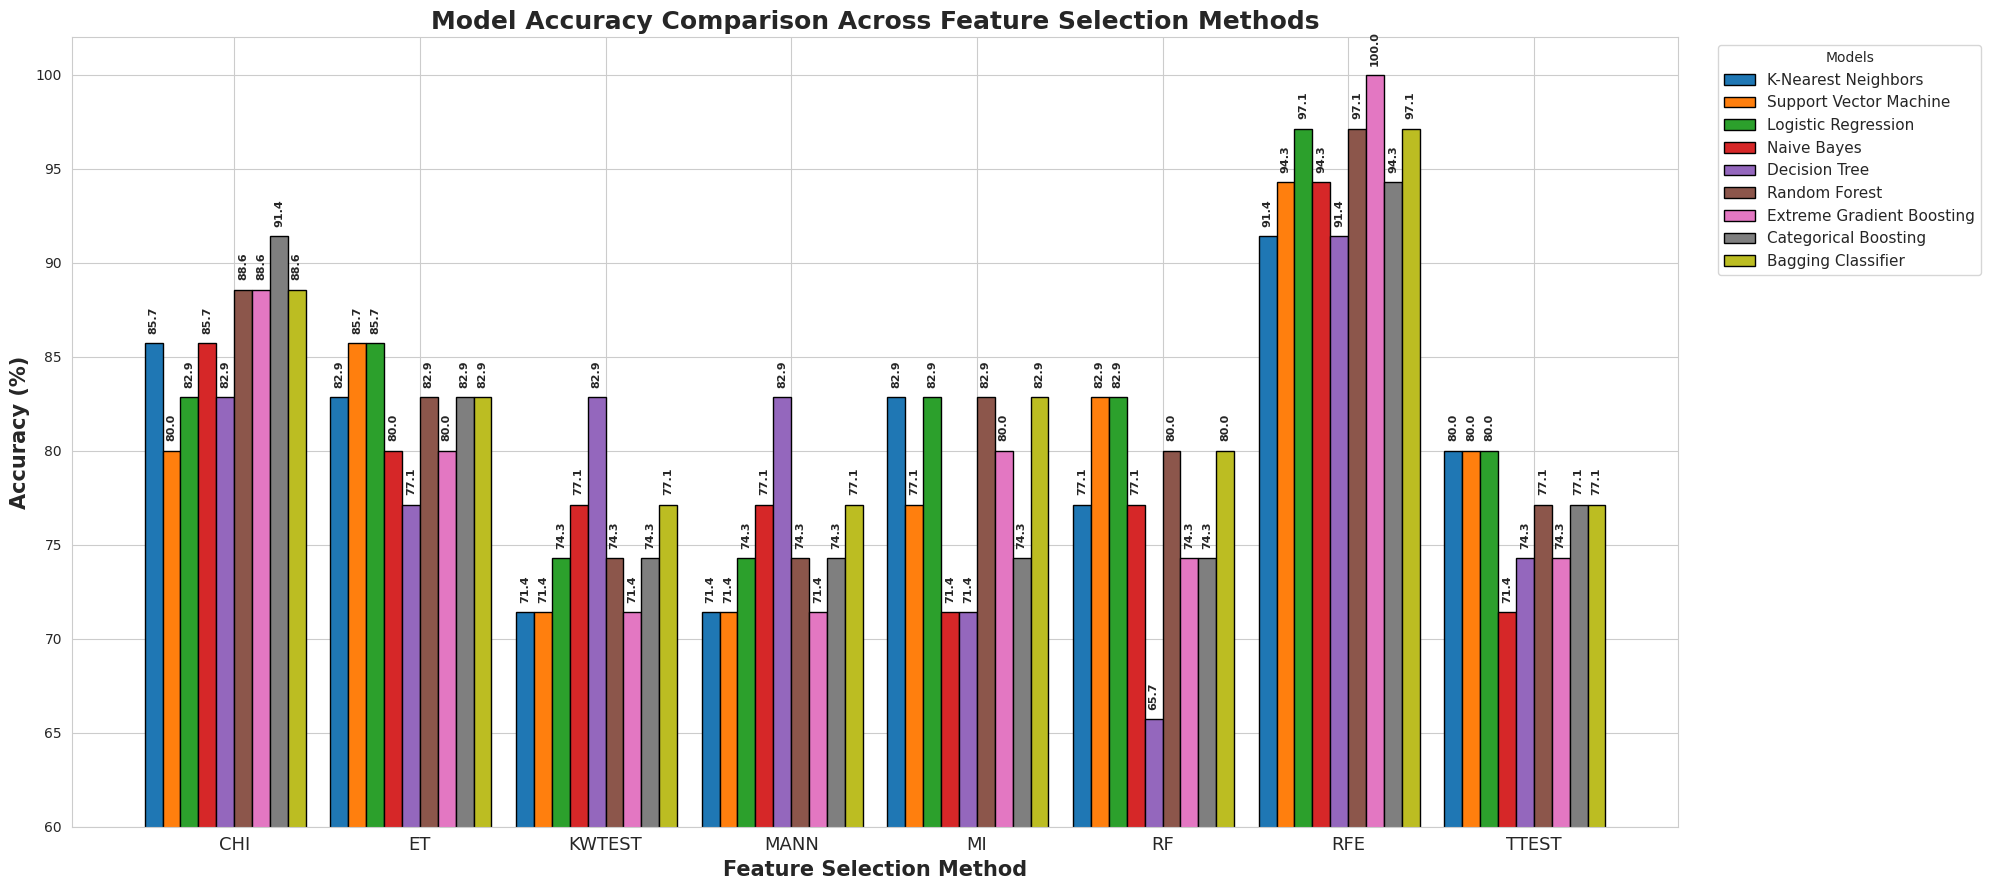

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
results_df = pd.read_csv("results.csv")

# Standardize Feature Selection name
results_df['Feature Selection'] = results_df['Feature Selection'].replace('KWTest', 'KWTEST')

results_df["Accuracy"] = results_df["Accuracy"] * 100

# Aggregate duplicates
results_df = results_df.groupby(['Feature Selection', 'Model'], as_index=False).agg({
    'Accuracy': 'mean',
    'Threshold': 'mean'
})

pivot_df = results_df.pivot(index="Feature Selection",
                            columns="Model",
                            values="Accuracy")

sns.set_style("whitegrid")

# ✅ FIXED MODEL ORDER
model_order = [
    "KNN",
    "SVM",
    "Logistic Regression",
    "Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "CatBoost",
    "Bagged Tree"
]

# ✅ FULL NAMES FOR LEGEND
model_full_names = {
    "KNN": "K-Nearest Neighbors",
    "SVM": "Support Vector Machine",
    "Logistic Regression": "Logistic Regression",
    "Naive Bayes": "Naive Bayes",
    "Decision Tree": "Decision Tree",
    "Random Forest": "Random Forest",
    "XGBoost": "Extreme Gradient Boosting",
    "CatBoost": "Categorical Boosting",
    "Bagged Tree": "Bagging Classifier"
}

# ✅ REORDER COLUMNS
pivot_df = pivot_df[model_order]

feature_methods = pivot_df.index
models = model_order

# Spacing
x = np.arange(len(feature_methods)) * 1.4
width = 0.135   # slightly adjusted for 9 models

plt.figure(figsize=(20,9))

colors = sns.color_palette("tab10", len(models))

for i, model in enumerate(models):

    bars = plt.bar(x + i*width,
                   pivot_df[model],
                   width=width,
                   label=model_full_names[model],   # ✅ full names here
                   color=colors[i],
                   edgecolor="black")

    # Labels above bars
    for bar in bars:
        height = bar.get_height()

        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.5,
                 f"{height:.1f}",
                 ha='center',
                 va='bottom',
                 fontsize=8,
                 rotation=90,
                 fontweight="bold")

# Axis formatting
plt.ylim(60,102)
plt.yticks(np.arange(60,101,5))

plt.xlabel("Feature Selection Method",
           fontsize=15,
           fontweight="bold")

plt.ylabel("Accuracy (%)",
           fontsize=15,
           fontweight="bold")

plt.title("Model Accuracy Comparison Across Feature Selection Methods",
          fontsize=18,
          fontweight="bold")

plt.xticks(x + width*(len(models)/2),
           feature_methods,
           fontsize=13)

plt.legend(title="Models",
           bbox_to_anchor=(1.02,1),
           loc="upper left",
           fontsize=11)

plt.tight_layout()
plt.show()

Best Feature Selector: RFE


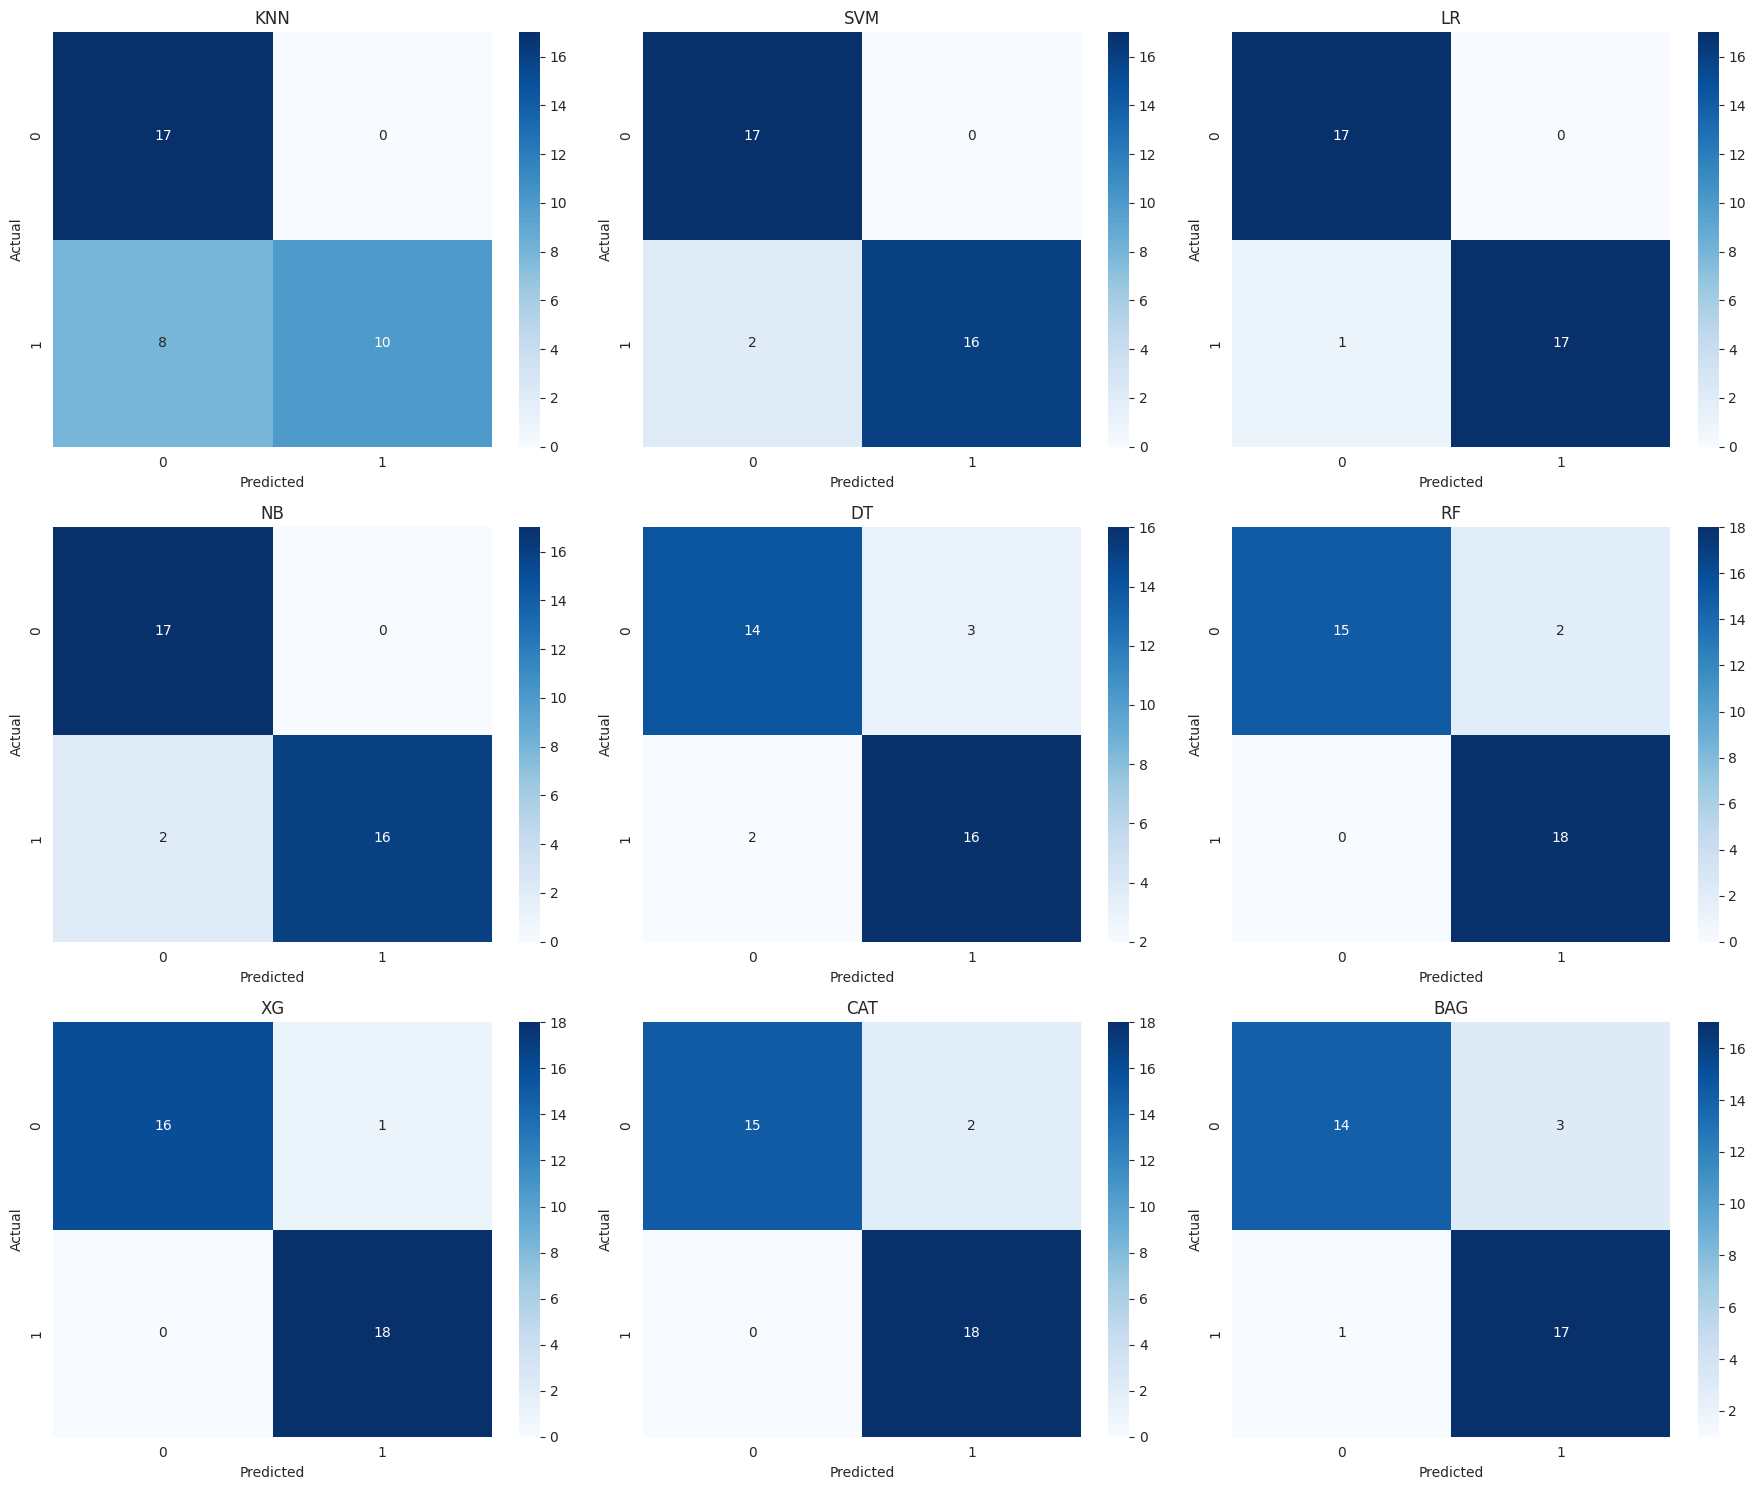

In [ ]:
best_fs = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Feature Selection"]

print("Best Feature Selector:", best_fs)

if best_fs == "MI":
    X_train_best, X_test_best = X_train_MI_pca, X_test_MI_pca
    y_train_best, y_test_best = y_train_MI, y_test_MI

elif best_fs == "TTEST":
    X_train_best, X_test_best = X_train_TTEST_pca, X_test_TTEST_pca
    y_train_best, y_test_best = y_train_TTEST, y_test_TTEST

elif best_fs == "MANN":
    X_train_best, X_test_best = X_train_MANN_pca, X_test_MANN_pca
    y_train_best, y_test_best = y_train_MANN, y_test_MANN

elif best_fs == "CHI":
    X_train_best, X_test_best = X_train_CHI_pca, X_test_CHI_pca
    y_train_best, y_test_best = y_train_CHI, y_test_CHI

elif best_fs == "RF":
    X_train_best, X_test_best = X_train_RF_pca, X_test_RF_pca
    y_train_best, y_test_best = y_train_RF, y_test_RF

elif best_fs == "ET":
    X_train_best, X_test_best = X_train_ET_pca, X_test_ET_pca
    y_train_best, y_test_best = y_train_ET, y_test_ET

elif best_fs == "RFE":
    X_train_best, X_test_best = X_train_RFE_pca, X_test_RFE_pca
    y_train_best, y_test_best = y_train_RFE, y_test_RFE

elif best_fs == "KWTEST":
    X_train_best, X_test_best = X_train_KW_pca, X_test_KW_pca
    y_train_best, y_test_best = y_train_KW, y_test_KW

models = [
("KNN", KNeighborsClassifier(n_neighbors=7)),
("SVM", SVC(C=100, kernel="rbf", gamma=0.01, probability=True)),
("LR", LogisticRegression(max_iter=5000)),
("NB", GaussianNB()),
("DT", DecisionTreeClassifier(max_depth=8)),
("RF", RandomForestClassifier(n_estimators=500)),
("XG", XGBClassifier(eval_metric="logloss")),
("CAT", CatBoostClassifier(verbose=0)),
("BAG", BaggingClassifier(estimator=DecisionTreeClassifier()))
]

from sklearn.metrics import confusion_matrix

plt.figure(figsize=(18,15))

for i, (name, model) in enumerate(models):

    model.fit(X_train_best, y_train_best)

    y_pred = model.predict(X_test_best)

    cm = confusion_matrix(y_test_best, y_pred)

    plt.subplot(3,3,i+1)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

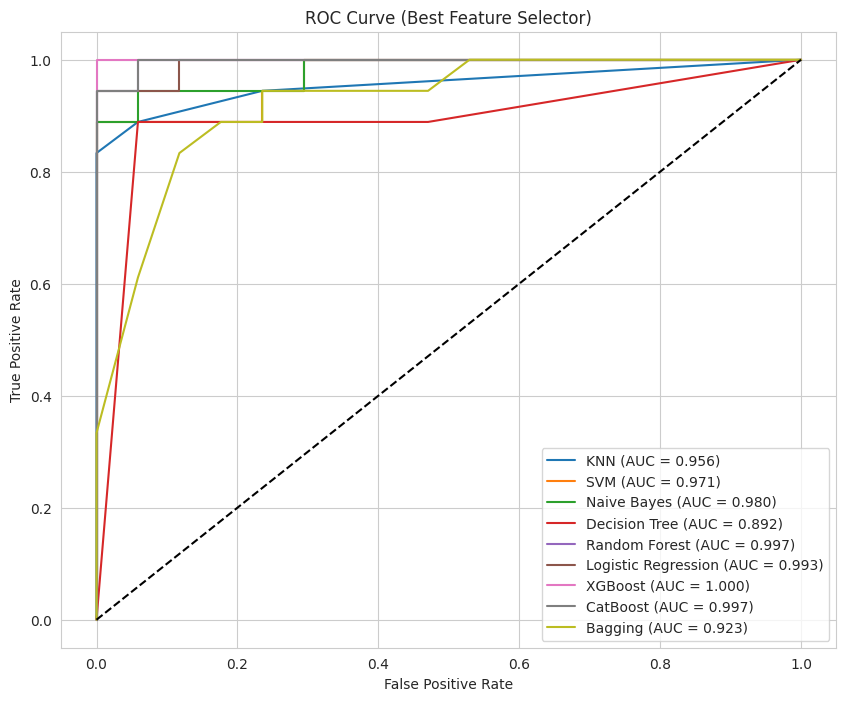

In [ ]:
from sklearn.metrics import roc_curve, auc

models = {
"KNN": KNeighborsClassifier(n_neighbors=7),
"SVM": SVC(C=100, kernel="rbf", gamma=0.01, probability=True),
"Naive Bayes": GaussianNB(),
"Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_split=5),
"Random Forest": RandomForestClassifier(n_estimators=500, random_state=42),
"Logistic Regression": LogisticRegression(max_iter=5000),
"XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss"),
"CatBoost": CatBoostClassifier(verbose=0),
"Bagging": BaggingClassifier(estimator=DecisionTreeClassifier())
}

plt.figure(figsize=(10,8))

for name, model in models.items():

    model.fit(X_train_best, y_train_best)

    y_prob = model.predict_proba(X_test_best)[:,1]

    fpr, tpr, _ = roc_curve(y_test_best, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve (Best Feature Selector)")

plt.legend()
plt.show()

In [ ]:
# print(results_df.columns)
data = pd.read_csv("results.csv")
print(data.columns)

Index(['Feature Selection', 'Model', 'Threshold', 'Accuracy'], dtype='object')


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

final_results = []

sr_no = 1

# Fixed model order (same as your graph)
model_order = [
    "KNN",
    "SVM",
    "Logistic Regression",
    "Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "CatBoost",
    "Bagged Tree"
]

for fs_method in results_df["Feature Selection"].unique():

    for model_name in model_order:

        subset = results_df[
            (results_df["Feature Selection"] == fs_method) &
            (results_df["Model"] == model_name)
        ]

        if subset.empty:
            continue

        acc = subset["Accuracy"].values[0]
        threshold = subset["Threshold"].values[0] if "Threshold" in subset.columns else None

        # 🔥 GET DATASET (same logic like confusion matrix block)
        if fs_method == "MI":
            X_tr, X_te, y_tr, y_te = X_train_MI_pca, X_test_MI_pca, y_train_MI, y_test_MI
        elif fs_method == "TTEST":
            X_tr, X_te, y_tr, y_te = X_train_TTEST_pca, X_test_TTEST_pca, y_train_TTEST, y_test_TTEST
        elif fs_method == "MANN":
            X_tr, X_te, y_tr, y_te = X_train_MANN_pca, X_test_MANN_pca, y_train_MANN, y_test_MANN
        elif fs_method == "CHI":
            X_tr, X_te, y_tr, y_te = X_train_CHI_pca, X_test_CHI_pca, y_train_CHI, y_test_CHI
        elif fs_method == "RF":
            X_tr, X_te, y_tr, y_te = X_train_RF_pca, X_test_RF_pca, y_train_RF, y_test_RF
        elif fs_method == "ET":
            X_tr, X_te, y_tr, y_te = X_train_ET_pca, X_test_ET_pca, y_train_ET, y_test_ET
        elif fs_method == "RFE":
            X_tr, X_te, y_tr, y_te = X_train_RFE_pca, X_test_RFE_pca, y_train_RFE, y_test_RFE
        elif fs_method == "KWTEST":
            X_tr, X_te, y_tr, y_te = X_train_KW_pca, X_test_KW_pca, y_train_KW, y_test_KW
        else:
            continue

        # 🔥 MODEL SELECT
        if model_name == "KNN":
            model = KNeighborsClassifier(n_neighbors=7)
        elif model_name == "SVM":
            model = SVC(C=100, kernel="rbf", gamma=0.01, probability=True)
        elif model_name == "Naive Bayes":
            model = GaussianNB()
        elif model_name == "Decision Tree":
            model = DecisionTreeClassifier(max_depth=8)
        elif model_name == "Random Forest":
            model = RandomForestClassifier(n_estimators=500)
        elif model_name == "Logistic Regression":
            model = LogisticRegression(max_iter=5000)
        elif model_name == "XGBoost":
            model = XGBClassifier(eval_metric="logloss")
        elif model_name == "CatBoost":
            model = CatBoostClassifier(verbose=0)
        elif model_name == "Bagged Tree":
            model = BaggingClassifier(estimator=DecisionTreeClassifier())
        else:
            continue

        # Train
        model.fit(X_tr, y_tr)

        # Predictions
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:,1]

        # Metrics
        precision = precision_score(y_te, y_pred)
        recall = recall_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred)
        auc = roc_auc_score(y_te, y_prob)

        final_results.append([
            sr_no,
            model_name,
            fs_method,
            round(acc,2),
            round(precision*100,2),
            round(recall*100,2),
            round(f1*100,2),
            round(auc*100,2),
            round(threshold,2)
        ])

        sr_no += 1

# Create DataFrame
final_df = pd.DataFrame(final_results, columns=[
    "Sr No",
    "Model",
    "Feature Selector",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)",
    "AUC (%)",
    "Threshold"
])

# ---------------------------
# SORT (Model + Feature Selector)
# ---------------------------
fs_order = ["CHI","ET","KWTEST","MANN","MI","RF","RFE","TTEST"]

final_df["Model"] = pd.Categorical(
    final_df["Model"],
    categories=model_order,
    ordered=True
)

final_df["Feature Selector"] = pd.Categorical(
    final_df["Feature Selector"],
    categories=fs_order,
    ordered=True
)

final_df = final_df.sort_values(
    by=["Model", "Feature Selector"]
).reset_index(drop=True)


# ---------------------------
# GROUP FORMAT (PDF STYLE)
# ---------------------------
final_grouped = []

current_model = None
sr_no = 1

for _, row in final_df.iterrows():

    if row["Model"] != current_model:
        current_model = row["Model"]

        final_grouped.append([
            sr_no,
            row["Model"],
            row["Feature Selector"],
            row["Accuracy (%)"],
            row["Precision (%)"],
            row["Recall (%)"],
            row["F1 Score (%)"],
            row["AUC (%)"],
            row["Threshold"]
        ])

        sr_no += 1

    else:
        final_grouped.append([
            "",
            "",
            row["Feature Selector"],
            row["Accuracy (%)"],
            row["Precision (%)"],
            row["Recall (%)"],
            row["F1 Score (%)"],
            row["AUC (%)"],
            row["Threshold"]
        ])


# Convert to DataFrame
final_df_grouped = pd.DataFrame(final_grouped, columns=[
    "Sr No",
    "Model",
    "Feature Selector",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)",
    "AUC (%)",
    "Threshold"
])


# Save CSV
final_df_grouped.to_csv("final_results_paper_format.csv", index=False)

print("✅ Final CSV saved in paper format")

✅ Final CSV saved in paper format


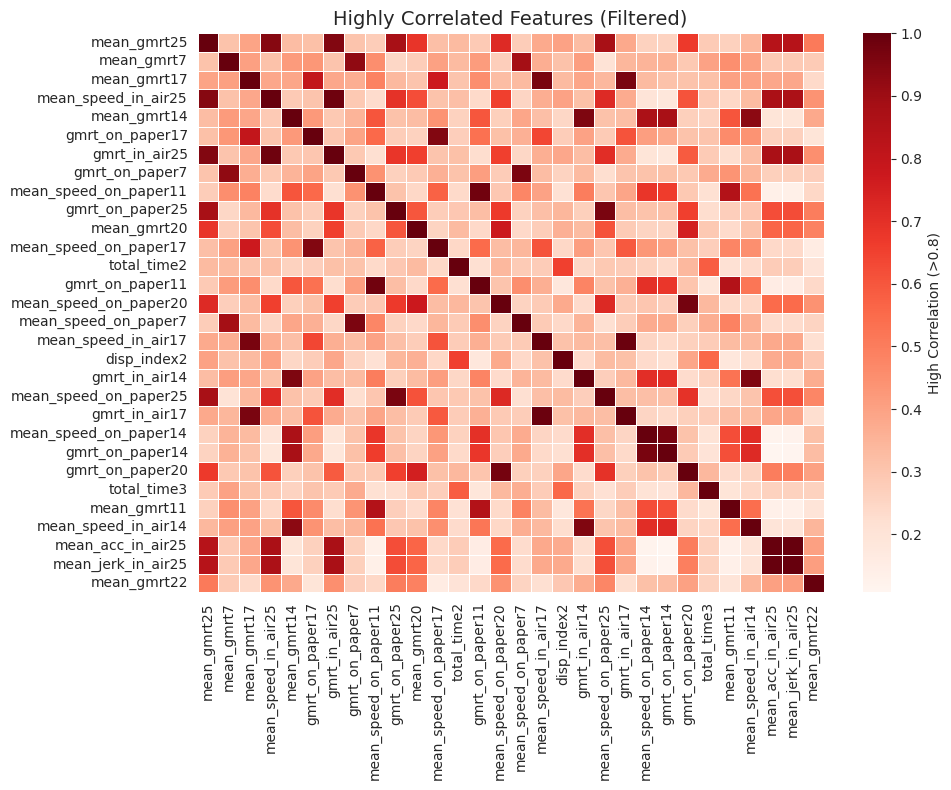

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data.csv")

# Drop ID if exists
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Separate features
X = df.drop("class", axis=1)

# Select top features (reduce clutter)
top_n = 30
corr = X.corr().abs()

# Select features with highest variance/correlation
top_features = corr.sum().sort_values(ascending=False).head(top_n).index
corr_subset = corr.loc[top_features, top_features]

# Mask upper triangle (clean look)
#mask = np.triu(np.ones_like(corr_subset, dtype=bool))

#threshold = 0.8
filtered_corr = corr_subset.copy()
#filtered_corr[filtered_corr] = np.nan

plt.figure(figsize=(10,8))
sns.heatmap(
    filtered_corr,
    #mask=mask,
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "High Correlation (>0.8)"}
)

plt.title("Highly Correlated Features (Filtered)", fontsize=14)
plt.tight_layout()
plt.savefig("high_corr_heatmap.png", dpi=300)
plt.show()

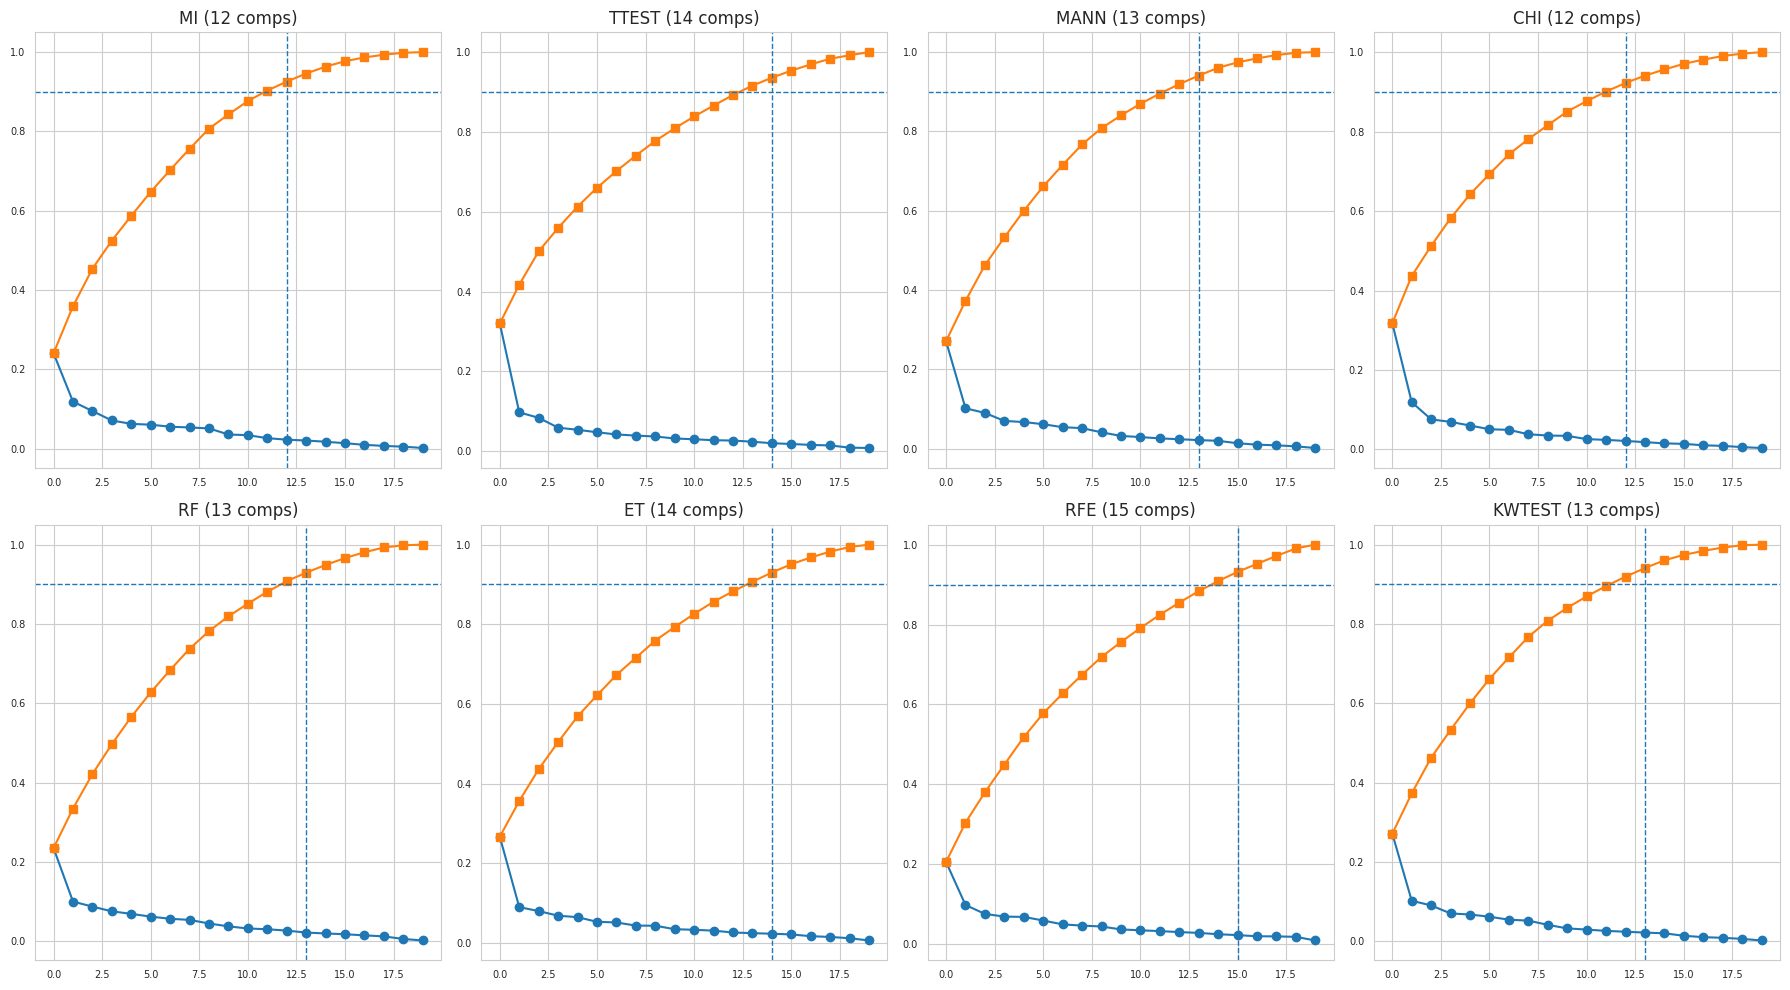

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Store datasets in dictionary
datasets = {
    "MI": X_train_MI,
    "TTEST": X_train_TTEST,
    "MANN": X_train_MANN,
    "CHI": X_train_CHI,
    "RF": X_train_RF,
    "ET": X_train_ET,
    "RFE": X_train_RFE,
    "KWTEST": X_train_KW
}

plt.figure(figsize=(18,10))

for i, (name, data) in enumerate(datasets.items(), 1):

    pca = PCA()
    pca.fit(data)

    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # Find 90% threshold
    n_comp = np.argmax(cumulative_var >= 0.90) + 1

    # Plot
    plt.subplot(2,4,i)

    plt.plot(explained_var[:20], marker='o', label='Var')
    plt.plot(cumulative_var[:20], marker='s', label='Cum Var')

    plt.axhline(y=0.90, linestyle='--', linewidth=1)
    plt.axvline(x=n_comp, linestyle='--', linewidth=1)

    plt.title(f"{name} ({n_comp} comps)")
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)

plt.tight_layout()
plt.savefig("pca_all_methods.png", dpi=300)
plt.show()

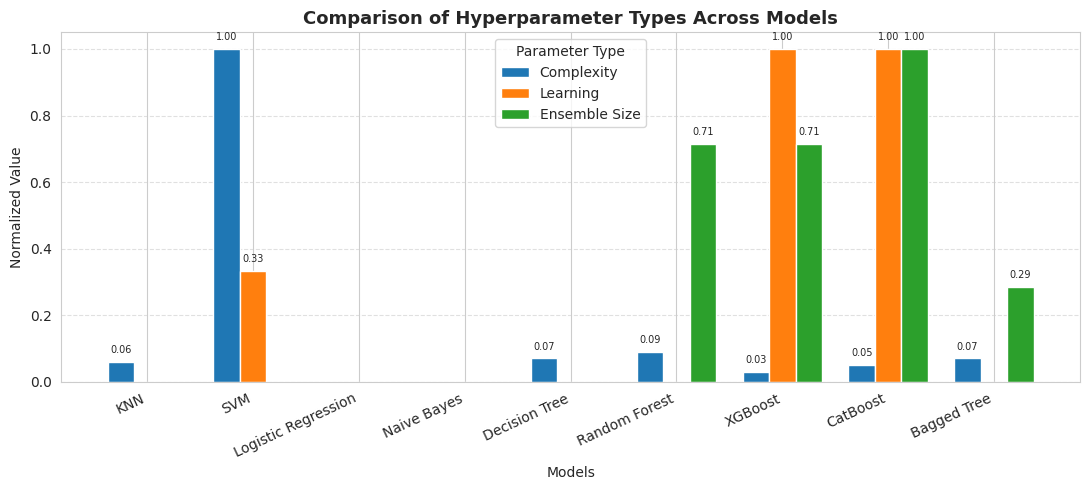

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Group hyperparameters logically
# -----------------------------
data = {
    "Model": [
        "KNN",
        "SVM",
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "CatBoost",
        "Bagged Tree"
    ],

    # Model complexity (depth / neighbors / C / iterations proxy)
    "Complexity": [
        7,      # KNN (neighbors)
        100,    # SVM (C)
        1,      # Logistic Regression (linear model)
        1,      # Naive Bayes (simple model → low complexity)
        8,      # Decision Tree (depth)
        10,     # RF (implicit depth proxy)
        4,      # XGBoost (depth)
        6,      # CatBoost (depth)
        8       # Bagged Tree (depth)
    ],

    # Learning parameter (learning rate / gamma)
    "Learning": [
        0,      # KNN
        0.01,   # SVM (gamma)
        0,      # LR
        0,      # NB
        0,      # DT
        0,      # RF
        0.03,   # XGB
        0.03,   # CatBoost
        0       # Bagging
    ],

    # Ensemble size / iterations
    "Ensemble Size": [
        0,      # KNN
        0,      # SVM
        0,      # LR
        0,      # NB
        0,      # DT
        500,    # RF
        500,    # XGB
        700,    # CatBoost
        200     # Bagging
    ]
}

df = pd.DataFrame(data)

# -----------------------------
# Normalize (keep for fair comparison)
# -----------------------------
df_norm = df.copy()
for col in ["Complexity","Learning","Ensemble Size"]:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-8)

# -----------------------------
# Plot (Improved)
# -----------------------------
fig, ax = plt.subplots(figsize=(11,5))

x = np.arange(len(df_norm["Model"]))
width = 0.25

bars1 = ax.bar(x - width, df_norm["Complexity"], width, label="Complexity")
bars2 = ax.bar(x, df_norm["Learning"], width, label="Learning")
bars3 = ax.bar(x + width, df_norm["Ensemble Size"], width, label="Ensemble Size")

# -----------------------------
# Add value labels (clean)
# -----------------------------
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0.02:   # avoid clutter
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.02,
                f"{height:.2f}",
                ha='center',
                va='bottom',
                fontsize=7
            )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# -----------------------------
# Formatting
# -----------------------------
ax.set_title("Comparison of Hyperparameter Types Across Models",
             fontsize=13, fontweight='bold')

ax.set_ylabel("Normalized Value")
ax.set_xlabel("Models")

ax.set_xticks(x)
ax.set_xticklabels(df["Model"], rotation=25, ha='right')

ax.legend(title="Parameter Type")
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("figure7_final.png", dpi=300)
plt.show()

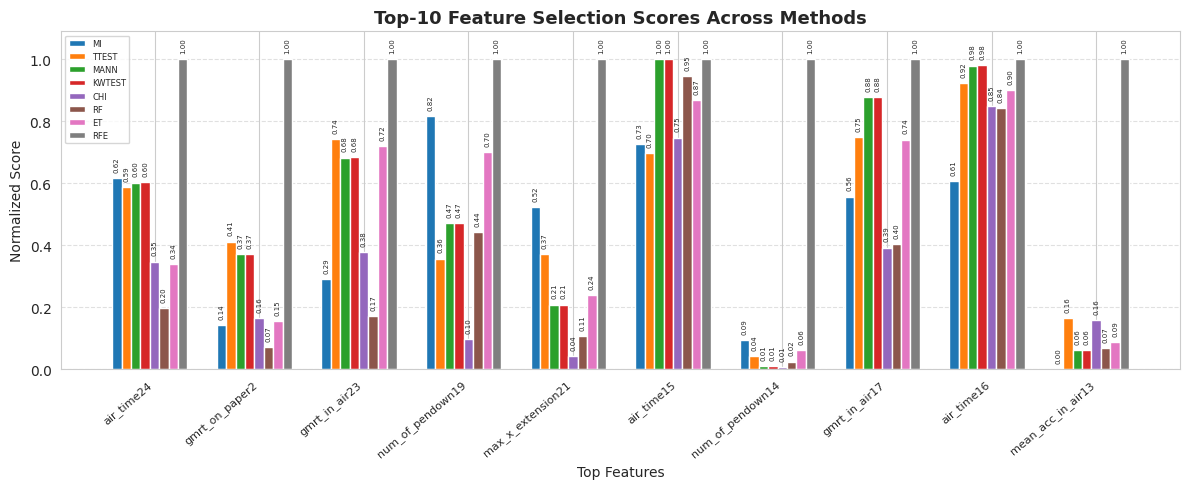

In [ ]:
# -----------------------------
# CLEAN BAR CHART (Top-10 + Values on top)
# -----------------------------

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")

# Select Top 10 features (important for clarity)
top10 = df_scores.sort_values(by="RFE", ascending=False).head(10)

features = top10["Feature"]
methods = ["MI","TTEST","MANN","KWTEST","CHI","RF","ET","RFE"]

x = np.arange(len(features))
width = 0.09  # thinner bars for spacing

plt.figure(figsize=(12,5))

# Plot bars
for i, method in enumerate(methods):
    values = top10[method]
    bars = plt.bar(x + i*width, values, width, label=method)

    # Add value labels (horizontal)
    # for bar in bars:
    #     height = bar.get_height()
    #     if height > 0.15:   # avoid clutter for very small values
    #         plt.text(
    #             bar.get_x() + bar.get_width()/2,
    #             height + 0.02,
    #             f"{height:.2f}",
    #             ha='center',
    #             va='bottom',
    #             fontsize=6,
    #             rotation=90   # horizontal
    #         )
    for bar in bars:
        height = bar.get_height()
        plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.02,
                f"{height:.2f}",
                ha='center',
                va='bottom',
                fontsize=5,
                rotation=90   # horizontal
            )

# Formatting
plt.xticks(x + width*len(methods)/2, features, rotation=40, ha='right', fontsize=8)
plt.ylabel("Normalized Score")
plt.xlabel("Top Features")
plt.title("Top-10 Feature Selection Scores Across Methods", fontsize=13, fontweight='bold')

plt.legend(ncol=1, fontsize=6)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0.0, 1.09)
plt.tight_layout()
plt.savefig("figure5_final.png", dpi=300)
plt.show()

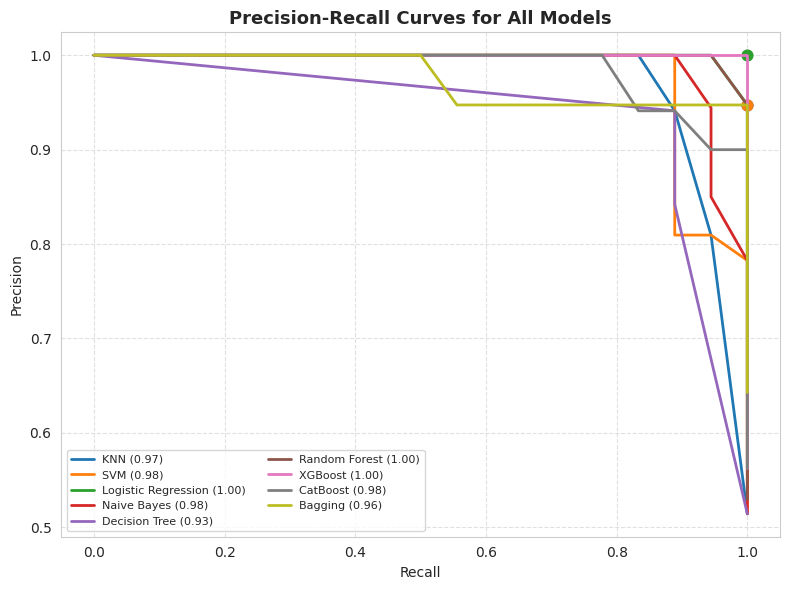

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# ALL models
# -----------------------------
all_models = {
    "KNN": knn,
    "SVM": svm,
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "CatBoost": cat,
    "Bagging": bag
}

plt.figure(figsize=(8,6))

for name, model in all_models.items():

    # Train
    model.fit(X_train_best, y_train_best)

    # Probabilities
    y_prob = model.predict_proba(X_test_best)[:,1]

    # PR curve
    precision, recall, thresholds = precision_recall_curve(y_test_best, y_prob)
    pr_auc = auc(recall, precision)

    # Smooth + sort for clean curve
    recall_sorted_idx = np.argsort(recall)
    recall = recall[recall_sorted_idx]
    precision = precision[recall_sorted_idx]

    # Smooth precision (monotonic)
    precision = np.maximum.accumulate(precision[::-1])[::-1]

    # Plot (clean line)
    plt.plot(recall, precision, linewidth=2,
            label=f"{name} ({pr_auc:.2f})")

    # -----------------------------
    # Mark best threshold (only for top models to avoid clutter)
    # -----------------------------
    if name in ["Random Forest", "XGBoost", "Logistic Regression"]:
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        idx = np.argmax(f1)

        plt.scatter(recall[idx], precision[idx], s=60)

# -----------------------------
# Formatting
# -----------------------------
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for All Models",
          fontsize=13, fontweight='bold')

plt.legend(fontsize=8, ncol=2)  # multi-column legend
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("figure8_all_models.png", dpi=300)
plt.show()

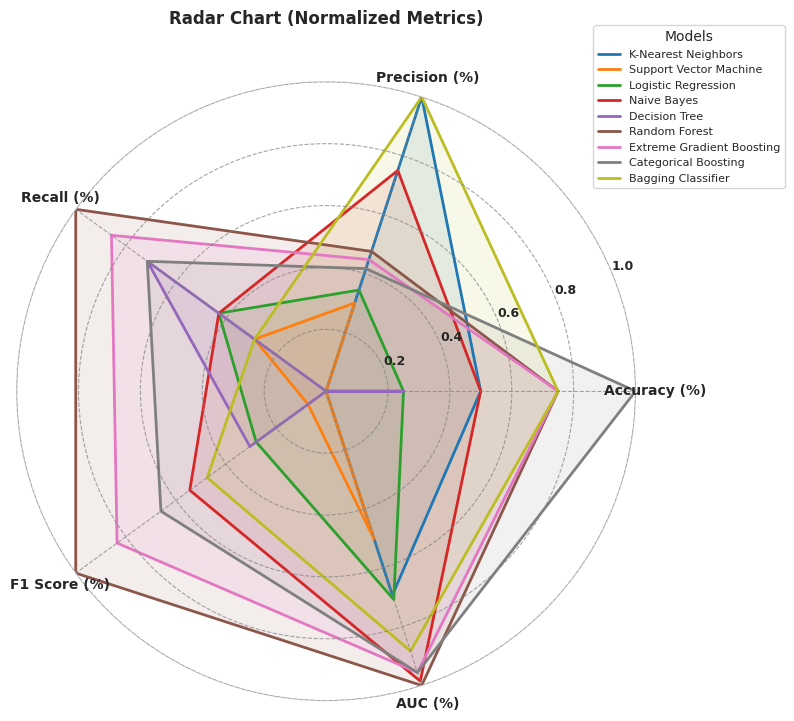

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load YOUR results CSV
# -----------------------------
df = pd.read_csv("final_results_paper_format.csv")

# Remove rows with NaN
df = df.dropna()

# Keep only required columns
metrics = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)", "AUC (%)"]
df = df[["Model"] + metrics]

# -----------------------------
# 2. Sort models by performance (AUC)
# -----------------------------
df = df.sort_values(by="AUC (%)", ascending=False)

# Normalize (important)
df_scaled = df.copy()
for col in metrics:
    df_scaled[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-8)

labels = metrics
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for model in model_order:
    row = df_scaled[df_scaled["Model"] == model]

    if row.empty:
        continue

    values = row[metrics].values.flatten().tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=model_full_names[model]   # ✅ full name here
    )

    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

# -----------------------------
# Styling (AXIS + TICKS)
# -----------------------------
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=9, fontweight='bold')

ax.set_axisbelow(False)

ax.yaxis.grid(True, color='gray', linestyle='--', alpha=0.7)
ax.xaxis.grid(True, color='gray', linestyle='--', alpha=0.7)

ax.tick_params(axis='y', pad=10)

# 👉 Move title upward
plt.title("Radar Chart (Normalized Metrics)",
          fontsize=12, fontweight='bold', y=1.08)

# 👉 Adjust layout spacing
plt.subplots_adjust(top=0.85, bottom=0.05)

# 👉 Move legend slightly outside
plt.legend(title="Models", loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=8)
plt.tight_layout(pad=2)

plt.tight_layout()
plt.show()